# L+ tide results

Fig 8 = L+ regimes for MOM6 experiments

In [1]:
#Load required packages
%matplotlib inline
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cftime
import IPython.display
import cmocean as cm
import sys, os
import warnings
warnings.simplefilter("ignore")
from dask.distributed import Client


In [2]:
list_folders_base = ['layer-thermo-on-warm_CC','layer-thermo-on-cold_CC',
               'layer-thermo-on-warm_SF','layer-thermo-on-cold_SF']
suffixes = ['','-ustarmin','-u01tides','-u005tides','-u001tides','-u02tides','-MK18']
list_folders_MOM6 = []
for n in np.arange(len(suffixes)):
    list_folders_MOM6 = np.append(list_folders_MOM6, [x+suffixes[n] for x in list_folders_base])
print(list_folders_MOM6)

base_folder_MOM6 = '/g/data/x77/cy8964/mom6/archive/'

## define some useful functions
ymax = 720
def open_files_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    try:
        prog = xr.open_dataset(base + '/output000/prog__0002_002.nc')#,chunks={'Time': 10}).chunk({'Time': 10,'yh':40,'xh':240,'yq':40,'xq':240})
    except FileNotFoundError:
        print('year 1 output')
        prog = xr.open_dataset(base + '/output000/prog__0001_002.nc')
    #ocean_daily_z = xr.open_dataset(base + 'output000/ocean_daily_z.nc')
    ocean_geometry = xr.open_dataset(base + "/output000/ocean_geometry.nc")
    return prog, ocean_geometry
def open_ocean_daily_z_MOM6(i):
    base = base_folder_MOM6 + list_folders_MOM6[i]
    prog = xr.open_dataset(base + '/output000/ocean_daily_z_steadymean.nc')#,chunks={'time': 10}).chunk({'time': 10,'yh':40,'xh':240,'yq':40,'xq':240})
    return prog

def plot_Lplus(ax,i,vmin1,vmax1,cmap):
    ocean_daily_z = open_ocean_daily_z_MOM6(i)
    file_name = list_folders_MOM6[i]
    print(file_name)
    label = list_folders_MOM6[i]
    s_to_year = 3600*24*365
    dataplot = ocean_daily_z.lplus.isel(time = 0)
    
    p1 = dataplot.plot.contourf(ax = ax, cmap = cmap, levels = [0,2500,1e4], extend = 'both',add_colorbar = False)
        
    ax.set_ylabel('y (km)', fontsize = 13)
    ax.set_xlabel('x (km)', fontsize = 13)
    ax.set_title('$L^+$ , ' +label)

    return p1



['layer-thermo-on-warm_CC' 'layer-thermo-on-cold_CC'
 'layer-thermo-on-warm_SF' 'layer-thermo-on-cold_SF'
 'layer-thermo-on-warm_CC-ustarmin' 'layer-thermo-on-cold_CC-ustarmin'
 'layer-thermo-on-warm_SF-ustarmin' 'layer-thermo-on-cold_SF-ustarmin'
 'layer-thermo-on-warm_CC-u01tides' 'layer-thermo-on-cold_CC-u01tides'
 'layer-thermo-on-warm_SF-u01tides' 'layer-thermo-on-cold_SF-u01tides'
 'layer-thermo-on-warm_CC-u005tides' 'layer-thermo-on-cold_CC-u005tides'
 'layer-thermo-on-warm_SF-u005tides' 'layer-thermo-on-cold_SF-u005tides'
 'layer-thermo-on-warm_CC-u001tides' 'layer-thermo-on-cold_CC-u001tides'
 'layer-thermo-on-warm_SF-u001tides' 'layer-thermo-on-cold_SF-u001tides'
 'layer-thermo-on-warm_CC-u02tides' 'layer-thermo-on-cold_CC-u02tides'
 'layer-thermo-on-warm_SF-u02tides' 'layer-thermo-on-cold_SF-u02tides'
 'layer-thermo-on-warm_CC-MK18' 'layer-thermo-on-cold_CC-MK18'
 'layer-thermo-on-warm_SF-MK18' 'layer-thermo-on-cold_SF-MK18']


# Plot Lplus

['layer-thermo-on-warm_CC' 'layer-thermo-on-cold_CC'
 'layer-thermo-on-warm_SF' 'layer-thermo-on-cold_SF'
 'layer-thermo-on-warm_CC-ustarmin' 'layer-thermo-on-cold_CC-ustarmin'
 'layer-thermo-on-warm_SF-ustarmin' 'layer-thermo-on-cold_SF-ustarmin'
 'layer-thermo-on-warm_CC-u005tides' 'layer-thermo-on-cold_CC-u005tides'
 'layer-thermo-on-warm_SF-u005tides' 'layer-thermo-on-cold_SF-u005tides'
 'layer-thermo-on-warm_CC-u01tides' 'layer-thermo-on-cold_CC-u01tides'
 'layer-thermo-on-warm_SF-u01tides' 'layer-thermo-on-cold_SF-u01tides'
 'layer-thermo-on-warm_CC-u02tides' 'layer-thermo-on-cold_CC-u02tides'
 'layer-thermo-on-warm_SF-u02tides' 'layer-thermo-on-cold_SF-u02tides']
0.3.0
layer-thermo-on-warm_SF
layer-thermo-on-cold_SF
layer-thermo-on-warm_SF-ustarmin
layer-thermo-on-cold_SF-ustarmin
layer-thermo-on-warm_SF-u005tides
layer-thermo-on-cold_SF-u005tides
layer-thermo-on-warm_SF-u01tides
layer-thermo-on-cold_SF-u01tides
layer-thermo-on-warm_SF-u02tides
layer-thermo-on-cold_SF-u02tides


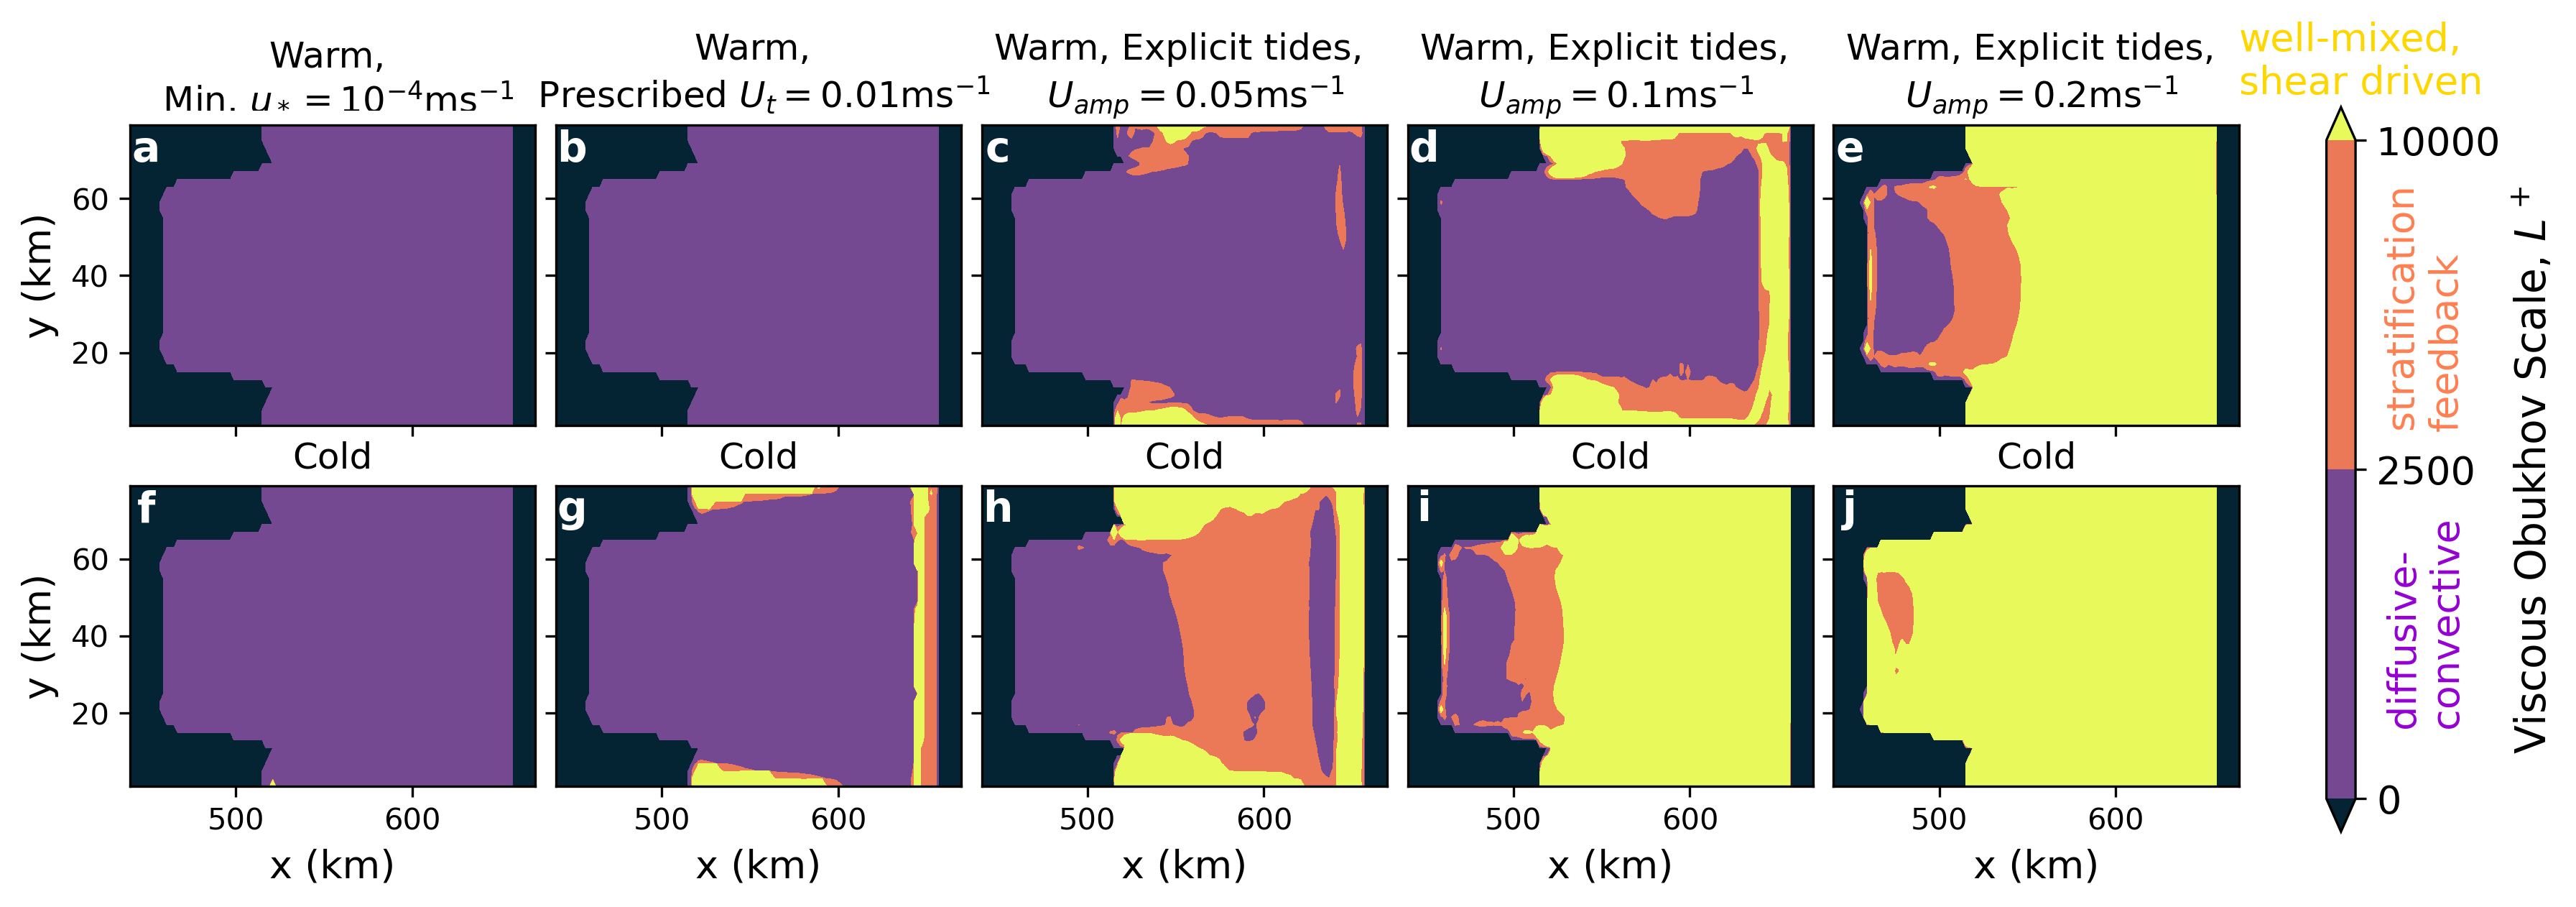

In [3]:
list_folders_base = ['layer-thermo-on-warm_CC','layer-thermo-on-cold_CC',
               'layer-thermo-on-warm_SF','layer-thermo-on-cold_SF']
suffixes = ['','-ustarmin','-u005tides','-u01tides','-u02tides']#,'-convectivelimitlocal']
list_folders = []
for n in np.arange(len(suffixes)):
    list_folders = np.append(list_folders, [x+suffixes[n] for x in list_folders_base])
print(list_folders)
list_folders_MOM6 = list_folders

fig, axes = plt.subplots(nrows = 2, ncols = 5,figsize = (13.5,4.2),dpi = 300)

time = np.arange(-180,0)
y = 20
x = 20


plot_Lplus(axes[0,1],2,0,4,cm.cm.thermal)
axes[0,1].set_title('Warm, \n Prescribed $U_t = 0.01$ms$^{-1}$')
plot_Lplus(axes[1,1],3,0,4,cm.cm.thermal)
axes[1,1].set_title('Cold')

plot_Lplus(axes[0,0],6,0,4,cm.cm.thermal)
axes[0,0].set_title('Warm, \n Min. $u_* = 10^{-4}$ms$^{-1}$')
plot_Lplus(axes[1,0],7,0,4,cm.cm.thermal)
axes[1,0].set_title('Cold')

plot_Lplus(axes[0,2],10,0,4,cm.cm.thermal)
axes[0,2].set_title('Warm, Explicit tides, \n '+r' $U_{amp} = 0.05$ms$^{-1}$')
plot_Lplus(axes[1,2],11,0,4,cm.cm.thermal)
axes[1,2].set_title('Cold')

plot_Lplus(axes[0,3],14,0,4,cm.cm.thermal)
axes[0,3].set_title('Warm, Explicit tides, \n '+ r'$U_{amp} = 0.1$ms$^{-1}$')
p1 = plot_Lplus(axes[1,3],15,0,4,cm.cm.thermal)
axes[1,3].set_title('Cold')

plot_Lplus(axes[0,4],18,0,4,cm.cm.thermal)
axes[0,4].set_title('Warm, Explicit tides, \n '+ r'$U_{amp} = 0.2$ms$^{-1}$')
p1 = plot_Lplus(axes[1,4],19,0,4,cm.cm.thermal)
axes[1,4].set_title('Cold')

cax = plt.axes([0.88,0.1,0.01,0.8])
cb = plt.colorbar(p1, cax = cax).set_label(size = 14, label = 'Viscous Obukhov Scale, $L^+$')

for j in np.arange(5):
    for k in np.arange(2):
        axes[k,j].set_xlim(440,670)

for j in np.arange(1,5):
    for k in np.arange(2):
        axes[k,j].set_ylabel('')
        axes[k,j].set_yticklabels('')

for j in np.arange(5):
    axes[0,j].set_xlabel('')
    axes[0,j].set_xticklabels('')
plt.tick_params(labelsize=13)
#plt.text(

plt.text(2,0.12, 'diffusive-\nconvective',rotation = 90,
        transform=cax.transAxes,color = 'darkviolet',fontsize = 13)
plt.text(2,0.57, 'stratification \nfeedback',rotation = 90,
        transform=cax.transAxes,color = 'coral',fontsize = 13)
plt.text(-3,1.07, 'well-mixed,\nshear driven',#rotation = 90
        transform=cax.transAxes,color = 'gold',fontsize = 13)

axes[0,0].text(0.04,0.92,'a',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[0,0].transAxes, fontsize = 14,color = 'w')
axes[0,1].text(0.04,0.92,'b',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[0,1].transAxes, fontsize = 14,color = 'w')
axes[0,2].text(0.04,0.92,'c',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[0,2].transAxes, fontsize = 14,color = 'w')
axes[0,3].text(0.04,0.92,'d',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[0,3].transAxes, fontsize = 14,color = 'w')
axes[0,4].text(0.04,0.92,'e',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[0,4].transAxes, fontsize = 14,color = 'w')
axes[1,0].text(0.04,0.92,'f',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[1,0].transAxes, fontsize = 14,color = 'w')
axes[1,1].text(0.04,0.92,'g',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[1,1].transAxes, fontsize = 14,color = 'w')
axes[1,2].text(0.04,0.92,'h',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[1,2].transAxes, fontsize = 14,color = 'w')
axes[1,3].text(0.04,0.92,'i',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[1,3].transAxes, fontsize = 14,color = 'w')
axes[1,4].text(0.04,0.92,'j',horizontalalignment='center', fontweight='bold',
     verticalalignment='center',transform=axes[1,4].transAxes, fontsize = 14,color = 'w')


fig.subplots_adjust(hspace = 0.2,wspace = 0.05, bottom = 0.15, right = 0.85)

fig.savefig('/g/data/x77/cy8964/ISOMIP/param-paper-plots/figs/Fig8.pdf')